In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [3]:
project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

data_file = project_folder / "data" / "student_requests.csv"
model_file = project_folder / "models" / "medical_classifier.joblib"
report_folder = project_folder / "reports"

report_folder.mkdir(exist_ok=True)

print("Project folder:", project_folder)
print("Dataset:", data_file)

Project folder: c:\Users\Kavithima Siluni\Desktop\MediSub
Dataset: c:\Users\Kavithima Siluni\Desktop\MediSub\data\student_requests.csv


In [4]:
data = pd.read_csv(data_file)

print(data.head())
print()
print("Number of questions:", len(data))
print()
print(data["category"].value_counts())

   id                                           question          category
0   1                 How do I submit a medical request?  PROCESS_GUIDANCE
1   2  What is the complete process for submitting a ...  PROCESS_GUIDANCE
2   3  What should I do after missing a lecture becau...  PROCESS_GUIDANCE
3   4  Can you explain the medical submission procedure?  PROCESS_GUIDANCE
4   5    I need help with the medical submission process  PROCESS_GUIDANCE

Number of questions: 26

category
OUT_OF_SCOPE             6
PROCESS_GUIDANCE         5
REFERENCE_NUMBER_HELP    5
DOCUMENT_REQUIREMENTS    5
MA_SUBMISSION_HELP       5
Name: count, dtype: int64


In [5]:
required_columns = {"id", "question", "category"}

if not required_columns.issubset(data.columns):
    raise ValueError("The dataset must contain id, question and category columns.")

data = data.dropna(subset=["question", "category"])
data["question"] = data["question"].astype(str).str.strip()
data["category"] = data["category"].astype(str).str.strip()

data = data[data["question"] != ""]
data = data.drop_duplicates(subset=["question"])

allowed_categories = {
    "PROCESS_GUIDANCE",
    "REFERENCE_NUMBER_HELP",
    "DOCUMENT_REQUIREMENTS",
    "MA_SUBMISSION_HELP",
    "OUT_OF_SCOPE"
}

invalid_categories = set(data["category"]) - allowed_categories

if invalid_categories:
    raise ValueError(f"Invalid categories found: {invalid_categories}")

print("Dataset checking completed.")
print("Remaining questions:", len(data))

Dataset checking completed.
Remaining questions: 26


In [6]:
questions = data["question"]
categories = data["category"]

X_train, X_test, y_train, y_test = train_test_split(
    questions,
    categories,
    test_size=0.20,
    random_state=42,
    stratify=categories
)

print("Training questions:", len(X_train))
print("Testing questions:", len(X_test))

Training questions: 20
Testing questions: 6


In [7]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [8]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, predictions, zero_division=0))

Accuracy: 0.5

                       precision    recall  f1-score   support

DOCUMENT_REQUIREMENTS       0.00      0.00      0.00         1
   MA_SUBMISSION_HELP       0.50      1.00      0.67         1
         OUT_OF_SCOPE       1.00      0.50      0.67         2
     PROCESS_GUIDANCE       0.50      1.00      0.67         1
REFERENCE_NUMBER_HELP       0.00      0.00      0.00         1

             accuracy                           0.50         6
            macro avg       0.40      0.50      0.40         6
         weighted avg       0.50      0.50      0.44         6



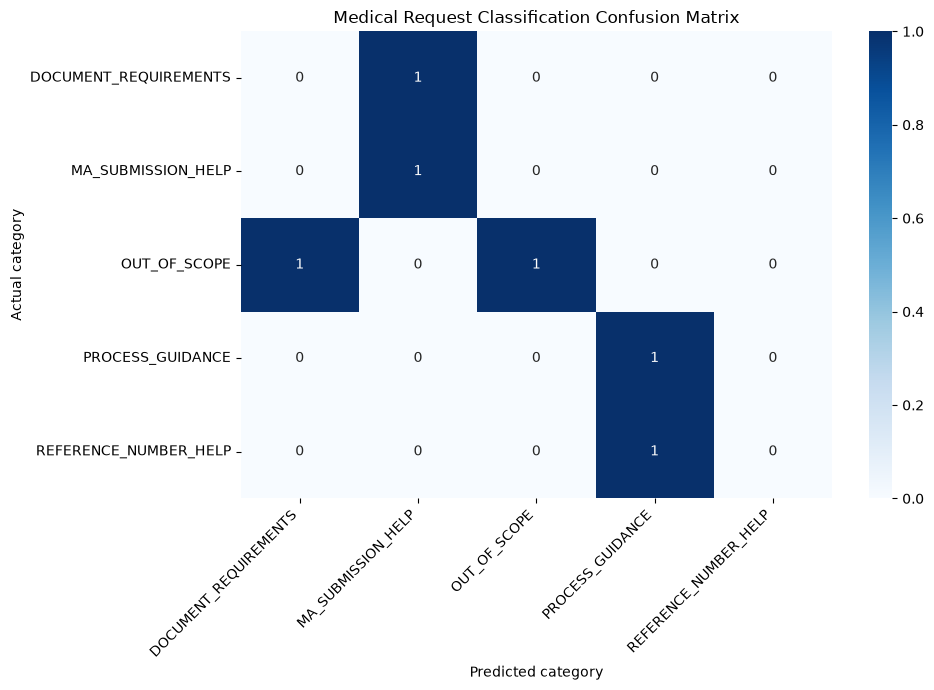

Saved: c:\Users\Kavithima Siluni\Desktop\MediSub\reports\confusion_matrix.png


In [9]:
labels = sorted(data["category"].unique())

matrix = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.title("Medical Request Classification Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

confusion_matrix_file = report_folder / "confusion_matrix.png"
plt.savefig(confusion_matrix_file)
plt.show()

print("Saved:", confusion_matrix_file)

In [10]:
joblib.dump(model, model_file)

print("Model saved to:", model_file)

Model saved to: c:\Users\Kavithima Siluni\Desktop\MediSub\models\medical_classifier.joblib


In [11]:
test_question = "What documents should I prepare?"

predicted_category = model.predict([test_question])[0]
probabilities = model.predict_proba([test_question])[0]
highest_probability = probabilities.max()

print("Question:", test_question)
print("Predicted category:", predicted_category)
print("Confidence:", round(highest_probability * 100, 2), "%")

Question: What documents should I prepare?
Predicted category: DOCUMENT_REQUIREMENTS
Confidence: 36.9 %
